In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore') 
sns.set_theme(style="whitegrid")


In [2]:

df = pd.read_csv('D:\loan_approval_dataset.csv')

# Sửa lỗi khoảng trắng thừa ngầm trong dữ liệu Kaggle
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


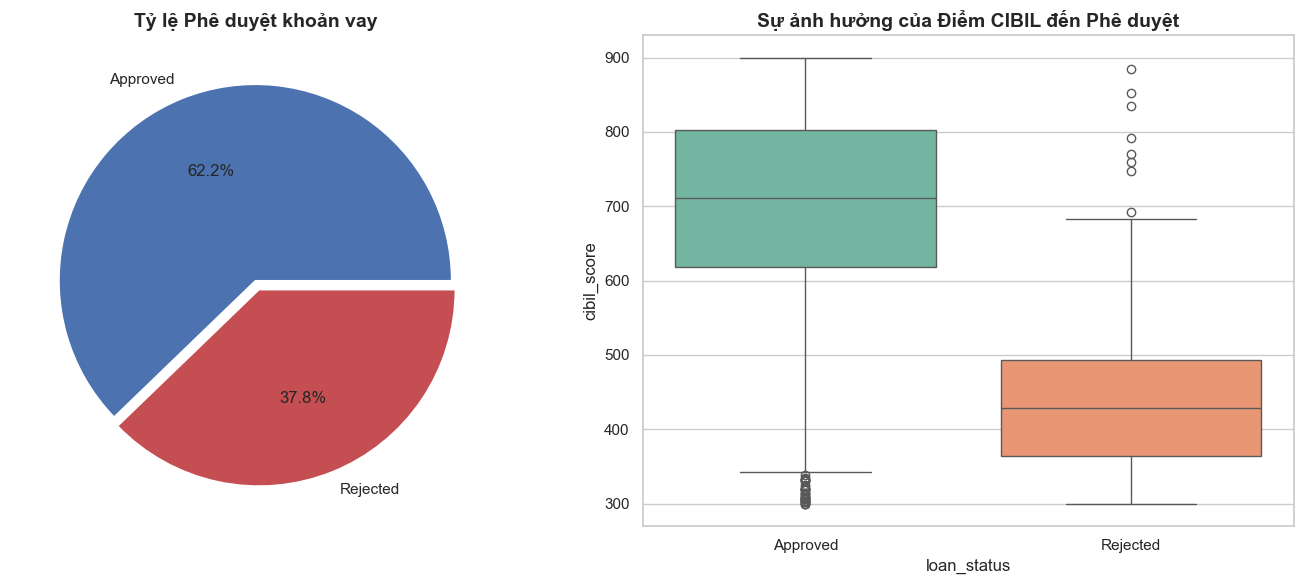

In [ ]:
# Trực quan hóa dữ liệu
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ 1: Tỷ lệ Duyệt / Từ chối khoản vay
status_counts = df['loan_status'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], explode=(0, 0.05))
axes[0].set_title('Tỷ lệ Phê duyệt khoản vay', fontsize=14, weight='bold')

# Biểu đồ 2: Ảnh hưởng của Điểm CIBIL đến quyết định duyệt vay
sns.boxplot(x='loan_status', y='cibil_score', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Sự ảnh hưởng của Điểm CIBIL đến Phê duyệt', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
## Tiền xử lý dữ liệu
df_processed = df.copy()

for col in ['education', 'self_employed', 'loan_status']:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])

# Tách đặc trưng (X) và nhãn dự đoán (y)
X = df_processed.drop(columns=['loan_id', 'loan_status'])
y = df_processed['loan_status'] 

# Chuẩn hóa StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia tập dữ liệu (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Số lượng mẫu Train : {X_train.shape[0]}")
print(f"Số lượng mẫu Test : {X_test.shape[0]}")

Số lượng mẫu Train (để học): 3415
Số lượng mẫu Test (để thi): 854


In [ ]:
# Huấn luyện và so sánh mô hình (Decision Tree vs Random Forest)
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
best_model = None
best_acc = 0
best_model_name = ""

for name, model in models.items():
    # Huấn luyện mô hình
    model.fit(X_train, y_train)
    # Dự đoán
    y_pred = model.predict(X_test)
    
    # Tính điểm
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })
    
    # Lưu lại mô hình tốt nhất để phân tích ở bước sau
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name

# Hiển thị bảng so sánh (tự động bôi màu xanh cho mô hình có điểm cao nhất)
df_results = pd.DataFrame(results)
display(df_results.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], color='lightgreen', axis=0))

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.977752,0.971609,0.968553,0.970079
1,Random Forest,0.978923,0.977707,0.965409,0.971519


--- MÔ HÌNH TỐT NHẤT LÀ: Random Forest ---


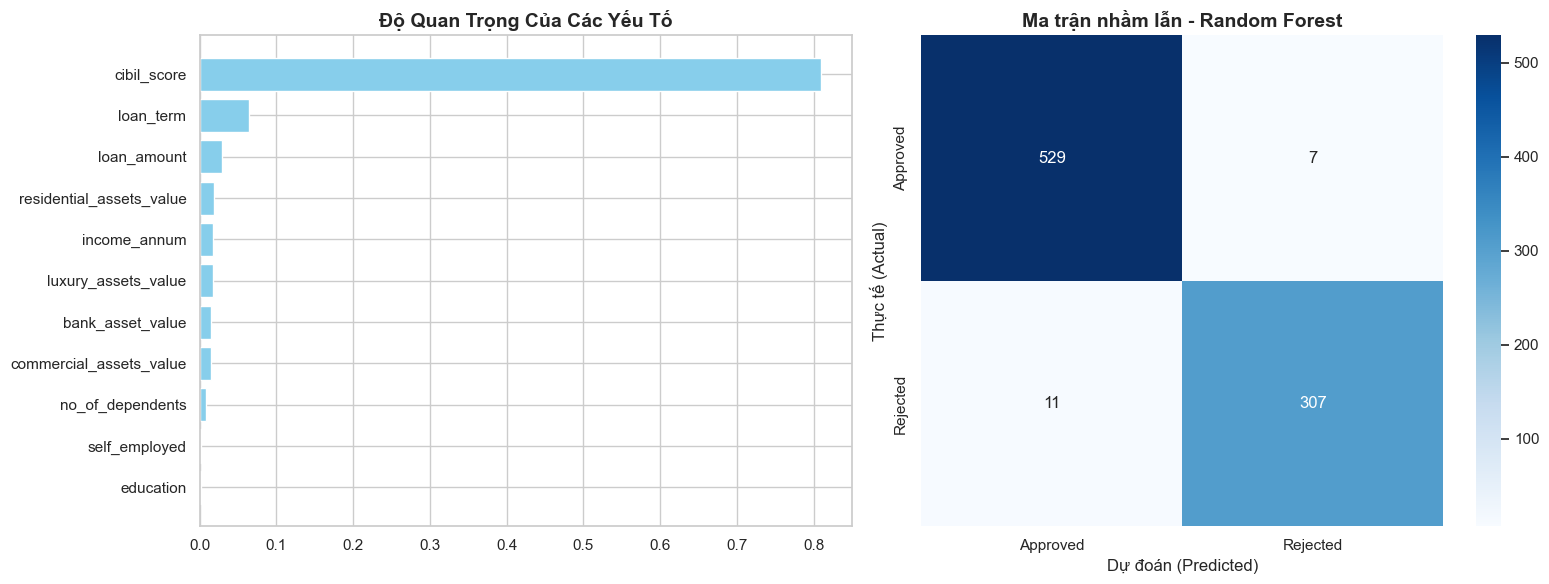

In [ ]:
# Phân tích chuyên sâu từ mô hình tốt nhất
print(f"--- MÔ HÌNH TỐT NHẤT LÀ: {best_model_name} ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ Độ quan trọng yếu tố (Feature Importance)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)
    
    axes[0].barh(range(len(indices)), importances[indices], color='skyblue', align='center')
    axes[0].set_yticks(range(len(indices)), [X.columns[i] for i in indices])
    axes[0].set_title('Độ Quan Trọng Của Các Yếu Tố', fontsize=14, weight='bold')

# 2. Ma trận nhầm lẫn (Confusion Matrix)
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Approved', 'Rejected'], 
            yticklabels=['Approved', 'Rejected'], ax=axes[1])
axes[1].set_title(f'Ma trận nhầm lẫn - {best_model_name}', fontsize=14, weight='bold')
axes[1].set_ylabel('Thực tế (Actual)')
axes[1].set_xlabel('Dự đoán (Predicted)')

plt.tight_layout()
plt.show()

In [ ]:
#  Nhập liệu và Dự đoán
import pandas as pd

print("="*50)
print(" HỆ THỐNG THẨM ĐỊNH KHOẢN VAY TỰ ĐỘNG ")
print("="*50)
print("Vui lòng nhập thông tin khách hàng (Nhấn Enter sau mỗi lần nhập):\n")

try:
    # 1. THU THẬP DỮ LIỆU TỪ BÀN PHÍM 
    no_of_dependents = int(input("1. Số người phụ thuộc (vd: 0, 1, 2): "))
    
    education = input("2. Học vấn (Gõ chính xác 'Graduate' hoặc 'Not Graduate'): ").strip()
    self_employed = input("3. Tự kinh doanh? (Gõ chính xác 'Yes' hoặc 'No'): ").strip()
    
    income_annum = int(input("4. Thu nhập hàng năm (VNĐ - vd: 8500000): "))
    loan_amount = int(input("5. Số tiền muốn vay (VNĐ - vd: 25000000): "))
    loan_term = int(input("6. Thời hạn vay (tháng - vd: 12, 24): "))
    
    cibil_score = int(input("7. Điểm tín dụng CIBIL (Từ 300 đến 900): "))
    
    residential_assets_value = int(input("8. Giá trị tài sản nhà đất (VNĐ): "))
    commercial_assets_value = int(input("9. Giá trị tài sản thương mại (VNĐ): "))
    luxury_assets_value = int(input("10. Giá trị tài sản xa xỉ (VNĐ): "))
    bank_asset_value = int(input("11. Giá trị tài sản ngân hàng (VNĐ): "))

    # Tạo dictionary từ dữ liệu vừa nhập
    new_customer = {
        'no_of_dependents': no_of_dependents,
        'education': education,
        'self_employed': self_employed,
        'income_annum': income_annum,
        'loan_amount': loan_amount,
        'loan_term': loan_term,
        'cibil_score': cibil_score,
        'residential_assets_value': residential_assets_value,
        'commercial_assets_value': commercial_assets_value,
        'luxury_assets_value': luxury_assets_value,
        'bank_asset_value': bank_asset_value
    }

    # 2. TIỀN XỬ LÝ DỮ LIỆU MỚI
    new_data = pd.DataFrame([new_customer])

    # Mã hóa chữ thành số (bắt lỗi nếu gõ sai chính tả)
    if education not in ['Graduate', 'Not Graduate'] or self_employed not in ['Yes', 'No']:
        print("\n LỖI: Cột Học vấn hoặc Tự kinh doanh bạn gõ sai chính tả. Vui lòng chạy lại ô này và gõ đúng định dạng!")
    else:
        new_data['education'] = new_data['education'].map({'Graduate': 0, 'Not Graduate': 1})
        new_data['self_employed'] = new_data['self_employed'].map({'No': 0, 'Yes': 1})

        # Đảm bảo thứ tự cột chuẩn
        new_data = new_data[X.columns]

        # Chuẩn hóa (sử dụng scaler từ Cell 4)
        new_data_scaled = scaler.transform(new_data)

        # 3. DỰ ĐOÁN
        # best_model đã được lưu từ Cell 5 (Random Forest)
        prediction = best_model.predict(new_data_scaled)

        # 4. IN KẾT QUẢ CỰC ĐẸP
        print("\n" + "="*50)
        print(" ĐANG XỬ LÝ DỮ LIỆU... ".center(50, '*'))
        print("="*50)
        
        if prediction[0] == 0:
            print("\n KẾT QUẢ: HỒ SƠ ĐƯỢC PHÊ DUYỆT (APPROVED) ".center(50))
            print(" Chúc mừng! Khách hàng có rủi ro thấp và đủ điều kiện nhận vốn.")
        else:
            print("\n KẾT QUẢ: HỒ SƠ BỊ TỪ CHỐI (REJECTED) ".center(50))
            print(" Rất tiếc, hệ thống đánh giá hồ sơ này có rủi ro tín dụng cao.")
        print("\n" + "="*50)

except ValueError:
    print("\n LỖI: Bạn đã nhập chữ vào ô yêu cầu nhập số. Vui lòng chạy lại ô này!")